# Data Quality Check: Entity-Linked Articles

This notebook cleans articles with entity matches from notebook 15 in 4 steps:
1. **Repetition Filtering** - Remove articles with excessive sentence duplication (within-article)
2. **Digest Filtering** - Remove multi-headline news roundups
3. **Cross-Article Repetition Filtering** - Remove articles containing sentences from earlier articles
4. **Length Filtering (Optional)** - Review and optionally filter length outliers

**Scope**: Only articles with company entity matches (from notebook 15) will be cleaned.

**Note**: The `article_id` in entity linking results refers to the DataFrame INDEX, not the article_id column.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from collections import Counter
from tqdm.auto import tqdm

# Setup plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries loaded")

✓ Libraries loaded


/home/le/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
# Load original articles dataset
articles = pd.read_csv("data/01_preprocessed/articles_cleaned_sections_from_2008.csv")
print(f"Loaded {len(articles):,} articles")

# Load entity linking results from notebook 15
linked_results = pd.read_parquet("data/articles_linked_improved_full.parquet")
print(f"Loaded {len(linked_results):,} entity links")
print(f"Articles with entity matches: {linked_results['article_id'].nunique():,}")

Loaded 135,962 articles
Loaded 32,644 entity links
Articles with entity matches: 19,708


## Filter to Entity-Linked Articles

We filter to only articles that have company entity matches from notebook 15.
The `article_id` in `linked_results` corresponds to the DataFrame **index**, not the `article_id` column.

In [3]:
# Get article indices with entity matches
articles_with_entity_matches = linked_results['article_id'].unique()

print("=" * 80)
print("FILTERING TO ENTITY-LINKED ARTICLES")
print("=" * 80)

# Filter using DataFrame index
articles_to_clean = articles.loc[articles_with_entity_matches].copy()

print(f"\n📊 Dataset Scope:")
print(f"  Original full dataset: {len(articles):,} articles")
print(f"  Articles with entity matches: {len(articles_to_clean):,} articles")
print(f"  Reduction: {len(articles) - len(articles_to_clean):,} articles ({(len(articles) - len(articles_to_clean))/len(articles)*100:.1f}%)")

# Calculate text lengths
articles_to_clean['title_length'] = articles_to_clean['title'].fillna('').astype(str).str.len()
articles_to_clean['summary_length'] = articles_to_clean['summary'].fillna('').astype(str).str.len()
articles_to_clean['total_length'] = articles_to_clean['title_length'] + articles_to_clean['summary_length']
articles_to_clean['word_count'] = articles_to_clean['summary'].fillna('').astype(str).str.split().str.len()

print(f"\n📏 Length distribution:")
print(articles_to_clean['total_length'].describe())

FILTERING TO ENTITY-LINKED ARTICLES

📊 Dataset Scope:
  Original full dataset: 135,962 articles
  Articles with entity matches: 19,708 articles
  Reduction: 116,254 articles (85.5%)



📏 Length distribution:
count    19708.000000
mean      1178.830526
std       2168.411765
min         34.000000
25%        186.000000
50%        211.000000
75%        266.000000
max      29881.000000
Name: total_length, dtype: float64


## Quality Filtering Functions

In [4]:
def extract_sentences(text, min_length=10):
    """
    Extract sentences from text by splitting on full stops.
    
    Args:
        text: Text to extract sentences from
        min_length: Minimum character length for a sentence to be included
        
    Returns:
        List of cleaned sentences (stripped, filtered by length)
    """
    if pd.isna(text) or not isinstance(text, str):
        return []
    
    # Split on full stop (.)
    sentences = text.split('.')
    # Strip whitespace and filter by minimum length
    sentences = [s.strip() for s in sentences if len(s.strip()) >= min_length]
    
    return sentences


def detect_repetition(text, min_phrase_length=10):
    """
    Detect repeated phrases in text.
    Returns the number of repetitions and most common repeated phrases.
    """
    if pd.isna(text) or not isinstance(text, str):
        return 0, []
    
    # Split into sentences
    sentences = re.split(r'[.!?]+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > min_phrase_length]
    
    # Count sentence occurrences
    sentence_counts = Counter(sentences)
    
    # Find repetitions (sentences appearing more than once)
    repetitions = {sent: count for sent, count in sentence_counts.items() if count > 1}
    
    total_repetitions = sum(count - 1 for count in repetitions.values())
    
    # Get top repeated phrases
    top_repeated = sorted(repetitions.items(), key=lambda x: x[1], reverse=True)[:5]
    
    return total_repetitions, top_repeated


def detect_cross_article_repetition(df, min_sentence_length=10):
    """
    Detect sentences that appear in multiple articles across the dataset.
    
    This function processes articles in DataFrame index order and tracks which
    sentences have been seen before. For each article, it counts how many of its
    sentences appeared in previously-processed articles.
    
    Args:
        df: DataFrame with articles (must have 'summary' column)
        min_sentence_length: Minimum sentence length to consider (default: 10 chars)
        
    Returns:
        DataFrame with added 'cross_article_repeated_sentences' column containing
        the count of sentences that appeared in earlier articles
    """
    # Dictionary to track first occurrence of each sentence
    # Key: sentence text, Value: article index where it first appeared
    sentence_first_seen = {}
    
    # Results: article index -> count of repeated sentences
    repeated_counts = {}
    
    print(f"Processing {len(df):,} articles in index order...\n")
    
    for idx in tqdm(df.index, desc="Detecting cross-article repetitions"):
        row = df.loc[idx]
        
        # Extract sentences from this article
        sentences = extract_sentences(row['summary'], min_length=min_sentence_length)
        
        # Count how many sentences were seen in earlier articles
        repeated_in_this_article = 0
        
        for sentence in sentences:
            if sentence in sentence_first_seen:
                # This sentence was seen in an earlier article
                repeated_in_this_article += 1
            else:
                # First time seeing this sentence - record this article
                sentence_first_seen[sentence] = idx
        
        repeated_counts[idx] = repeated_in_this_article
    
    # Add counts to dataframe
    df_copy = df.copy()
    df_copy['cross_article_repeated_sentences'] = 0
    for idx, count in repeated_counts.items():
        df_copy.at[idx, 'cross_article_repeated_sentences'] = count
    
    return df_copy


def is_digest_article(title, summary):
    """
    Detect if an article is a news digest/roundup with multiple short items.
    
    Indicators:
    - Multiple ">>Source:" markers (multiple news sources cited)
    - Digest-style titles (Greenwatch, Roundup, etc.)
    - Multiple distinct headlines within text
    
    Returns: (is_digest: bool, num_sources: int, digest_indicators: list)
    """
    if pd.isna(summary):
        return False, 0, []
    
    text = str(title) + " " + str(summary)
    text_lower = text.lower()
    
    indicators = []
    
    # Count source citations (>>Source:)
    source_pattern = r'>>[\s]*[Ss]ource:'
    num_sources = len(re.findall(source_pattern, text))
    
    if num_sources >= 3:  # 3+ sources indicates digest
        indicators.append(f"{num_sources} sources cited")
    
    # Digest-style title patterns
    digest_titles = [
        'greenwatch', 'roundup', 'news digest', 'news round-up', 
        'in brief', 'quick hits', 'news briefs', 'wrap-up', 'wrap up',
        'daily briefing', 'news summary', 'this week', 'weekly wrap'
    ]
    
    for pattern in digest_titles:
        if pattern in text_lower[:100]:  # Check in title/beginning
            indicators.append(f"Digest title: '{pattern}'")
            break
    
    # Multiple headline patterns
    headline_pattern = r'\?\s*>>\s*Source:'
    num_headlines = len(re.findall(headline_pattern, text))
    
    if num_headlines >= 2:
        indicators.append(f"{num_headlines} distinct headlines")
    
    # Decision: is it a digest?
    is_digest = num_sources >= 3 or len(indicators) >= 2
    
    return is_digest, num_sources, indicators

print("✓ Quality filtering functions defined")

✓ Quality filtering functions defined


## Step 1: Repetition Filtering

Remove articles with excessive repeated sentences (threshold: >5 repetitions).

In [5]:
print("=" * 80)
print("STEP 1: REPETITION FILTERING")
print("=" * 80)

print(f"\nAnalyzing {len(articles_to_clean):,} articles...\n")

# Detect repetitions
repetition_results = []
for idx in tqdm(articles_to_clean.index, desc="Detecting repetitions"):
    row = articles_to_clean.loc[idx]
    num_reps, top_reps = detect_repetition(row['summary'])
    repetition_results.append({
        'index': idx,
        'num_repetitions': num_reps
    })

# Add repetition counts
articles_to_clean['num_repetitions'] = 0
for result in repetition_results:
    articles_to_clean.at[result['index'], 'num_repetitions'] = result['num_repetitions']

# Filter
REPETITION_THRESHOLD = 5
highly_repetitive = articles_to_clean[articles_to_clean['num_repetitions'] > REPETITION_THRESHOLD]

articles_after_repetition = articles_to_clean[
    articles_to_clean['num_repetitions'] <= REPETITION_THRESHOLD
].copy()

print(f"\n📊 Repetition Analysis:")
print(f"  Articles with >0 repetitions: {(articles_to_clean['num_repetitions'] > 0).sum():,}")
print(f"  Articles with >{REPETITION_THRESHOLD} repetitions: {len(highly_repetitive):,}")

print(f"\n✅ After Repetition Filtering: {len(articles_after_repetition):,} articles retained")

STEP 1: REPETITION FILTERING

Analyzing 19,708 articles...



Detecting repetitions: 100%|██████████| 19708/19708 [00:01<00:00, 13385.25it/s]



📊 Repetition Analysis:
  Articles with >0 repetitions: 15
  Articles with >5 repetitions: 2

✅ After Repetition Filtering: 19,706 articles retained


## Step 2: Digest Article Filtering

Remove multi-headline digest articles (news roundups with ≥3 source citations).

In [6]:
print("=" * 80)
print("STEP 2: DIGEST FILTERING")
print("=" * 80)

print(f"\nAnalyzing {len(articles_after_repetition):,} articles...\n")

# Detect digest articles
digest_results = []
for idx in tqdm(articles_after_repetition.index, desc="Detecting digests"):
    row = articles_after_repetition.loc[idx]
    is_dig, num_src, inds = is_digest_article(row['title'], row['summary'])
    
    if is_dig:
        digest_results.append({
            'index': idx,
            'num_sources': num_src
        })

# Filter
digest_indices = [r['index'] for r in digest_results]
articles_after_digest = articles_after_repetition[
    ~articles_after_repetition.index.isin(digest_indices)
].copy()

print(f"\n📊 Digest Analysis:")
print(f"  Digest articles found: {len(digest_results):,}")

print(f"\n✅ After Digest Filtering: {len(articles_after_digest):,} articles retained")

STEP 2: DIGEST FILTERING

Analyzing 19,706 articles...



Detecting digests: 100%|██████████| 19706/19706 [00:01<00:00, 17719.92it/s]


📊 Digest Analysis:
  Digest articles found: 47

✅ After Digest Filtering: 19,659 articles retained


## Step 3: Cross-Article Repetition Filtering

Remove articles that contain sentences appearing in earlier articles (threshold: ≥3 repeated sentences).

Articles are processed in DataFrame index order - first occurrence is retained, subsequent occurrences are removed.

In [7]:
print("=" * 80)
print("STEP 3: CROSS-ARTICLE REPETITION FILTERING")
print("=" * 80)

print(f"\nAnalyzing {len(articles_after_digest):,} articles for cross-article repetitions...\n")
print("Note: Articles processed in index order - first occurrence retained, duplicates removed.\n")

# Detect cross-article repetitions
articles_with_cross_reps = detect_cross_article_repetition(
    articles_after_digest, 
    min_sentence_length=10
)

# Define threshold
CROSS_ARTICLE_REPETITION_THRESHOLD = 3

# Identify articles with excessive cross-article repetition
cross_article_repetitive = articles_with_cross_reps[
    articles_with_cross_reps['cross_article_repeated_sentences'] >= CROSS_ARTICLE_REPETITION_THRESHOLD
]

# Filter to remove repetitive articles
articles_after_cross_repetition = articles_with_cross_reps[
    articles_with_cross_reps['cross_article_repeated_sentences'] < CROSS_ARTICLE_REPETITION_THRESHOLD
].copy()

# Statistics
print(f"\n📊 Cross-Article Repetition Analysis:")
print(f"  Articles with any cross-article repetition: {(articles_with_cross_reps['cross_article_repeated_sentences'] > 0).sum():,}")
print(f"  Articles with ≥{CROSS_ARTICLE_REPETITION_THRESHOLD} repeated sentences: {len(cross_article_repetitive):,}")
print(f"  Max repeated sentences in a single article: {articles_with_cross_reps['cross_article_repeated_sentences'].max():.0f}")

if len(cross_article_repetitive) > 0:
    print(f"\n📝 Sample of removed articles (top 5 by repetition count):")
    for i, (idx, row) in enumerate(cross_article_repetitive.nlargest(5, 'cross_article_repeated_sentences').iterrows(), 1):
        print(f"  {i}. [{row['cross_article_repeated_sentences']:.0f} repeated sentences] {row['title'][:70]}...")

print(f"\n✅ After Cross-Article Repetition Filtering: {len(articles_after_cross_repetition):,} articles retained")
print(f"   Removed: {len(cross_article_repetitive):,} articles ({len(cross_article_repetitive)/len(articles_after_digest)*100:.2f}%)")

STEP 3: CROSS-ARTICLE REPETITION FILTERING

Analyzing 19,659 articles for cross-article repetitions...

Note: Articles processed in index order - first occurrence retained, duplicates removed.

Processing 19,659 articles in index order...



Detecting cross-article repetitions: 100%|██████████| 19659/19659 [00:00<00:00, 20130.21it/s]



📊 Cross-Article Repetition Analysis:
  Articles with any cross-article repetition: 457
  Articles with ≥3 repeated sentences: 103
  Max repeated sentences in a single article: 170

📝 Sample of removed articles (top 5 by repetition count):
  1. [170 repeated sentences] Reinventing the wheel...
  2. [26 repeated sentences] Indigenous people in legal challenge against oil firms over tar sand p...
  3. [25 repeated sentences] Amazon rainforest threatened by new wave of oil and gas exploration...
  4. [20 repeated sentences] G20: Obama to pledge up to $3bn to help poor countries on climate chan...
  5. [17 repeated sentences] Going nowhere fast...

✅ After Cross-Article Repetition Filtering: 19,556 articles retained
   Removed: 103 articles (0.52%)


## Visualize Remaining Articles

After removing repetitions, digests, and cross-article repetitions, let's examine the length distribution of the remaining articles.

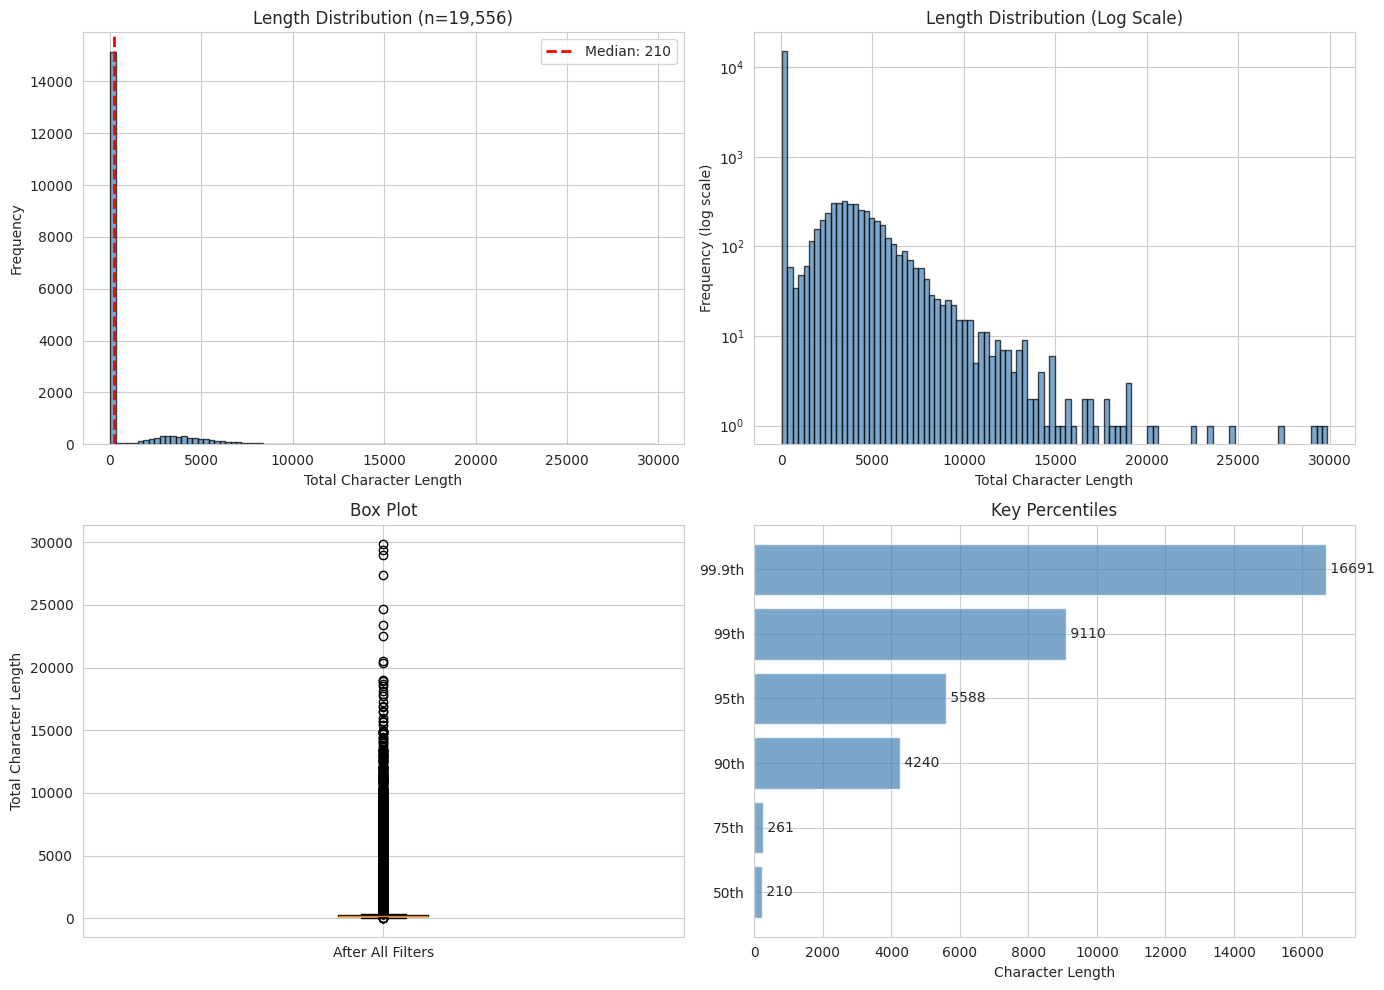


📊 Statistics (after all quality filters):
  Mean: 1159 | Median: 210
  Min: 34 | Max: 29881


In [8]:
# Visualize length distribution of remaining articles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram
axes[0, 0].hist(articles_after_cross_repetition['total_length'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Total Character Length')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Length Distribution (n={len(articles_after_cross_repetition):,})')
axes[0, 0].axvline(articles_after_cross_repetition['total_length'].median(), color='red', linestyle='--', linewidth=2, label=f'Median: {articles_after_cross_repetition["total_length"].median():.0f}')
axes[0, 0].legend()

# Log scale
axes[0, 1].hist(articles_after_cross_repetition['total_length'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].set_xlabel('Total Character Length')
axes[0, 1].set_ylabel('Frequency (log scale)')
axes[0, 1].set_title('Length Distribution (Log Scale)')
axes[0, 1].set_yscale('log')

# Box plot
axes[1, 0].boxplot(articles_after_cross_repetition['total_length'], vert=True)
axes[1, 0].set_ylabel('Total Character Length')
axes[1, 0].set_title('Box Plot')
axes[1, 0].set_xticklabels(['After All Filters'])

# Percentiles
percentiles = [50, 75, 90, 95, 99, 99.9]
values = [articles_after_cross_repetition['total_length'].quantile(p/100) for p in percentiles]
axes[1, 1].barh(range(len(percentiles)), values, color='steelblue', alpha=0.7)
axes[1, 1].set_yticks(range(len(percentiles)))
axes[1, 1].set_yticklabels([f'{p}th' for p in percentiles])
axes[1, 1].set_xlabel('Character Length')
axes[1, 1].set_title('Key Percentiles')
for i, (p, v) in enumerate(zip(percentiles, values)):
    axes[1, 1].text(v, i, f' {v:.0f}', va='center')

plt.tight_layout()
plt.show()

print(f"\n📊 Statistics (after all quality filters):")
print(f"  Mean: {articles_after_cross_repetition['total_length'].mean():.0f} | Median: {articles_after_cross_repetition['total_length'].median():.0f}")
print(f"  Min: {articles_after_cross_repetition['total_length'].min():.0f} | Max: {articles_after_cross_repetition['total_length'].max():.0f}")

## Step 4: IQR Length Filtering (Optional)

Review whether to apply IQR filtering on the remaining articles.

In [9]:
# Calculate IQR bounds on remaining articles
q1 = articles_after_cross_repetition['total_length'].quantile(0.25)
q3 = articles_after_cross_repetition['total_length'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("=" * 80)
print("STEP 4: IQR FILTERING REVIEW (NOT YET APPLIED)")
print("=" * 80)

print(f"\n📊 IQR Statistics:")
print(f"  Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f}")
print(f"  Lower bound={lower_bound:.0f}, Upper bound={upper_bound:.0f}")

# Preview what would be removed
would_remove_lower = articles_after_cross_repetition[articles_after_cross_repetition['total_length'] < lower_bound]
would_remove_upper = articles_after_cross_repetition[articles_after_cross_repetition['total_length'] > upper_bound]
would_remove_total = len(would_remove_lower) + len(would_remove_upper)

print(f"\n📋 Impact:")
print(f"  Would remove {len(would_remove_lower):,} SHORT + {len(would_remove_upper):,} LONG = {would_remove_total:,} total ({would_remove_total/len(articles_after_cross_repetition)*100:.2f}%)")
print(f"  Would retain: {len(articles_after_cross_repetition) - would_remove_total:,} ({(len(articles_after_cross_repetition) - would_remove_total)/len(articles_after_cross_repetition)*100:.2f}%)")

# Show examples
if len(would_remove_upper) > 0:
    print(f"\n📝 LONG articles that would be removed:")
    for i, (idx, row) in enumerate(would_remove_upper.nlargest(5, 'total_length').iterrows(), 1):
        print(f"  {i}. [{row['total_length']:.0f} chars] {row['title'][:60]}...")

if len(would_remove_lower) > 0:
    print(f"\n📝 SHORT articles that would be removed:")
    for i, (idx, row) in enumerate(would_remove_lower.nsmallest(5, 'total_length').iterrows(), 1):
        print(f"  {i}. [{row['total_length']:.0f} chars] {row['title'][:60]}...")

STEP 4: IQR FILTERING REVIEW (NOT YET APPLIED)

📊 IQR Statistics:
  Q1=185, Q3=261, IQR=76
  Lower bound=71, Upper bound=375

📋 Impact:
  Would remove 6 SHORT + 4,386 LONG = 4,392 total (22.46%)
  Would retain: 15,164 (77.54%)

📝 LONG articles that would be removed:
  1. [29881 chars] Meet the ‘inactivists’, tangling up the climate crisis in cu...
  2. [29332 chars] Invasion of the ‘frankenbees’: the danger of building a bett...
  3. [29004 chars] Revealed: the ‘carbon bombs’ set to trigger catastrophic cli...
  4. [27364 chars] Race to the bottom: the disastrous, blindfolded rush to mine...
  5. [24700 chars] Open letter to Shell's Ben van Beurden from John Ashton...

📝 SHORT articles that would be removed:
  1. [34 chars] FedEx’s Contractors...
  2. [41 chars] Google Thinks I’m Dead...
  3. [43 chars] Letters: Changes at Facebook...
  4. [48 chars] 45%...
  5. [57 chars] Anheuser-Busch InBev Buying Back Oriental Brewery...


## Classifier Quality Analysis

Let's analyze potential issues for downstream classification:

In [10]:
print("=" * 80)
print("CLASSIFIER QUALITY ANALYSIS")
print("=" * 80)

# 1. Check very short articles
very_short = articles_after_cross_repetition[articles_after_cross_repetition['total_length'] < 100]
print(f"\n📝 Very Short Articles (<100 chars): {len(very_short)} ({len(very_short)/len(articles_after_cross_repetition)*100:.2f}%)")
print("\nExamples:")
for idx, row in very_short.head(10).iterrows():
    print(f"  [{row['total_length']} chars] {row['title']}")
    print(f"    Summary: {row['summary'][:150]}")
    print()

# 2. Length distribution by percentile
print("\n📊 Percentile Breakdown:")
percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    val = articles_after_cross_repetition['total_length'].quantile(p/100)
    count = (articles_after_cross_repetition['total_length'] <= val).sum()
    print(f"  {p:2d}th percentile: {val:6.0f} chars ({count:5,} articles)")

# 3. Suggest more conservative thresholds
print("\n💡 Conservative Length Threshold Options:")
print(f"  • Minimum 100 chars: Would remove {len(very_short)} articles ({len(very_short)/len(articles_after_cross_repetition)*100:.2f}%)")

moderate_cutoff = articles_after_cross_repetition['total_length'].quantile(0.99)
very_long = articles_after_cross_repetition[articles_after_cross_repetition['total_length'] > moderate_cutoff]
print(f"  • Maximum {moderate_cutoff:.0f} chars (99th %ile): Would remove {len(very_long)} articles ({len(very_long)/len(articles_after_cross_repetition)*100:.2f}%)")

combined = len(very_short) + len(very_long)
print(f"  • Combined: Would remove {combined} articles ({combined/len(articles_after_cross_repetition)*100:.2f}%)")
print(f"  • Final retention: {len(articles_after_cross_repetition) - combined:,} articles ({(len(articles_after_cross_repetition) - combined)/len(articles_after_cross_repetition)*100:.2f}%)")

CLASSIFIER QUALITY ANALYSIS

📝 Very Short Articles (<100 chars): 35 (0.18%)

Examples:
  [34 chars] FedEx’s Contractors
    Summary: To the Editor:.

  [91 chars] Metropolitan Diary
    Summary: A visitor learns that a successful Metro card swipe depends on the wrist.

  [86 chars] A Lesson in Spilled Milk
    Summary: Greg Babe is the chief executive of the the Bayer Corporation.

  [98 chars] Google Seduces With Utility
    Summary: Some call it Big Brother, but who can resist? It’s just so darn useful.

  [66 chars] Social Network Diseases
    Summary: Can you get a computer virus from Facebook?

  [96 chars] Trained to Find a Way
    Summary: Eva Chen is the chief executive of Trend Micro, an antivirus software firm.

  [99 chars] What Jack Welch Taught Me
    Summary: Rick Smith is the chief executive of the credit bureau Equifax in Atlanta.

  [43 chars] Letters: Changes at Facebook
    Summary: To the Editor:.

  [89 chars] Qwest Exiting Wireless
    Summary: The company plans t

### Decision: Apply IQR Filtering?

Set `APPLY_IQR_FILTER = True` to apply filtering, or `False` to skip.

In [11]:
# Decision: Apply IQR filtering?
APPLY_IQR_FILTER = False  # Set to True to apply filtering

if APPLY_IQR_FILTER:
    print("✅ Applying IQR filtering...")
    outliers_lower = would_remove_lower
    outliers_upper = would_remove_upper
    total_outliers = would_remove_total
    
    articles_final_clean = articles_after_cross_repetition[
        (articles_after_cross_repetition['total_length'] >= lower_bound) & 
        (articles_after_cross_repetition['total_length'] <= upper_bound)
    ].copy()
    
    print(f"  Retained: {len(articles_final_clean):,} | Removed: {total_outliers:,}")
else:
    print("⏭️  SKIPPING IQR filtering - keeping all articles")
    articles_final_clean = articles_after_cross_repetition.copy()
    outliers_lower = pd.DataFrame()
    outliers_upper = pd.DataFrame()
    total_outliers = 0
    print(f"  Retained: {len(articles_final_clean):,}")

⏭️  SKIPPING IQR filtering - keeping all articles
  Retained: 19,556


## Final Summary

In [12]:
print("=" * 80)
print("FINAL SUMMARY: ENTITY-LINKED ARTICLE CLEANING")
print("=" * 80)

print(f"\n📊 Complete Filtering Pipeline:")
print(f"  1. Original (with entity matches): {len(articles_to_clean):,} articles")
print(f"  2. After repetition filter: {len(articles_after_repetition):,} (removed {len(highly_repetitive):,})")
print(f"  3. After digest filter: {len(articles_after_digest):,} (removed {len(digest_results):,})")
print(f"  4. After cross-article repetition filter: {len(articles_after_cross_repetition):,} (removed {len(cross_article_repetitive):,})")
if APPLY_IQR_FILTER:
    print(f"  5. After IQR filter: {len(articles_final_clean):,} (removed {total_outliers:,})")
else:
    print(f"  5. IQR filter: SKIPPED")

total_removed = len(articles_to_clean) - len(articles_final_clean)
print(f"\n✅ Total removed: {total_removed:,} ({total_removed/len(articles_to_clean)*100:.2f}%)")
print(f"✅ Final retention rate: {len(articles_final_clean)/len(articles_to_clean)*100:.2f}%")

print(f"\n📏 Final Dataset Characteristics:")
print(f"  Total articles: {len(articles_final_clean):,}")
print(f"  Length range: {articles_final_clean['total_length'].min():.0f} - {articles_final_clean['total_length'].max():.0f} chars")
print(f"  Median: {articles_final_clean['total_length'].median():.0f} chars")
print(f"  Mean: {articles_final_clean['total_length'].mean():.0f} chars")

# Check entity match retention
retained_indices = set(articles_final_clean.index)
entity_matches_retained = linked_results[linked_results['article_id'].isin(retained_indices)]

print(f"\n🔗 Entity Linking Coverage:")
print(f"  Original entity matches: {len(linked_results):,}")
print(f"  Entity matches retained: {len(entity_matches_retained):,} ({len(entity_matches_retained)/len(linked_results)*100:.1f}%)")
print(f"  Articles with entity matches: {entity_matches_retained['article_id'].nunique():,}")

FINAL SUMMARY: ENTITY-LINKED ARTICLE CLEANING

📊 Complete Filtering Pipeline:
  1. Original (with entity matches): 19,708 articles
  2. After repetition filter: 19,706 (removed 2)
  3. After digest filter: 19,659 (removed 47)
  4. After cross-article repetition filter: 19,556 (removed 103)
  5. IQR filter: SKIPPED

✅ Total removed: 152 (0.77%)
✅ Final retention rate: 99.23%

📏 Final Dataset Characteristics:
  Total articles: 19,556
  Length range: 34 - 29881 chars
  Median: 210 chars
  Mean: 1159 chars

🔗 Entity Linking Coverage:
  Original entity matches: 32,644
  Entity matches retained: 32,310 (99.0%)
  Articles with entity matches: 19,556


## Save Cleaned Dataset

In [13]:
# Prepare final dataset - keep entity matches that survived filtering
entity_matches_retained = linked_results[linked_results['article_id'].isin(articles_final_clean.index)]

# Prepare final dataset for export
articles_entity_linked_cleaned = articles_final_clean.drop(
    columns=['num_repetitions', 'cross_article_repeated_sentences'], 
    errors='ignore'
).copy()

# Calculate total removed
total_removed = len(articles_to_clean) - len(articles_final_clean)

# Save files
articles_entity_linked_cleaned.to_csv('data/01_preprocessed/articles_entity_linked_cleaned.csv', index=True)
articles_entity_linked_cleaned.to_parquet('data/01_preprocessed/articles_entity_linked_cleaned.parquet')

print("=" * 80)
print("✅ CLEANED DATASET SAVED")
print("=" * 80)

print(f"\n📁 Output files:")
print(f"  • data/01_preprocessed/articles_entity_linked_cleaned.csv")
print(f"  • data/01_preprocessed/articles_entity_linked_cleaned.parquet")

# Save comprehensive log
filtering_log = {
    'scope': 'entity_linked_articles',
    'note': 'Uses DataFrame INDEX from articles dataset to match article_id in linked_results',
    'original_count': len(articles_to_clean),
    'after_repetition_filter': len(articles_after_repetition),
    'after_digest_filter': len(articles_after_digest),
    'after_cross_article_repetition_filter': len(articles_after_cross_repetition),
    'after_iqr_filter': len(articles_final_clean),
    'total_removed': total_removed,
    'retention_rate': len(articles_final_clean) / len(articles_to_clean),
    'filters_applied': {
        'entity_match_filter': {
            'total_articles_in_corpus': len(articles),
            'articles_with_entity_matches': len(articles_to_clean),
            'matching_method': 'DataFrame index'
        },
        'repetition_filter': {
            'threshold': REPETITION_THRESHOLD,
            'removed': len(highly_repetitive)
        },
        'digest_filter': {
            'threshold_sources': 3,
            'removed': len(digest_results)
        },
        'cross_article_repetition_filter': {
            'threshold_repeated_sentences': CROSS_ARTICLE_REPETITION_THRESHOLD,
            'removed': len(cross_article_repetitive),
            'description': 'Removes articles with sentences appearing in earlier articles (first occurrence retained)'
        },
        'iqr_method': {
            'applied': APPLY_IQR_FILTER,
            'lower_bound': float(lower_bound) if APPLY_IQR_FILTER else None,
            'upper_bound': float(upper_bound) if APPLY_IQR_FILTER else None,
            'removed': total_outliers if APPLY_IQR_FILTER else 0
        }
    },
    'entity_linking_coverage': {
        'original_entity_matches': len(linked_results),
        'retained_entity_matches': len(entity_matches_retained),
        'entity_match_retention_rate': len(entity_matches_retained) / len(linked_results)
    },
    'final_statistics': {
        'median_length_chars': float(articles_final_clean['total_length'].median()),
        'mean_length_chars': float(articles_final_clean['total_length'].mean()),
        'min_length_chars': float(articles_final_clean['total_length'].min()),
        'max_length_chars': float(articles_final_clean['total_length'].max())
    }
}

with open('data/filtering_log_entity_linked.json', 'w') as f:
    json.dump(filtering_log, f, indent=2)

print(f"\n✅ Filtering log saved to: data/filtering_log_entity_linked.json")

# Save removed articles list
all_removed = []
if len(highly_repetitive) > 0:
    all_removed.append(highly_repetitive[['article_id', 'title', 'total_length', 'num_repetitions']].assign(reason='repetition'))
if len(digest_results) > 0:
    digest_df = articles_to_clean.loc[[r['index'] for r in digest_results]]
    digest_df_export = digest_df[['article_id', 'title', 'total_length']].assign(reason='digest')
    all_removed.append(digest_df_export)
if len(cross_article_repetitive) > 0:
    cross_rep_df_export = cross_article_repetitive[['article_id', 'title', 'total_length', 'cross_article_repeated_sentences']].assign(reason='cross_article_repetition')
    all_removed.append(cross_rep_df_export)
if total_outliers > 0:
    outliers_removed = pd.concat([outliers_lower, outliers_upper])
    outliers_removed_export = outliers_removed[['article_id', 'title', 'total_length']].assign(reason='iqr_outlier')
    all_removed.append(outliers_removed_export)

if all_removed:
    removed_articles = pd.concat(all_removed, ignore_index=False)
    removed_articles.to_csv('data/removed_articles_entity_linked.csv', index=True)
    print(f"✅ Removed articles list saved to: data/removed_articles_entity_linked.csv")

print(f"\n{'='*80}")
print("🎉 ENTITY-LINKED DATA CLEANING COMPLETE!")
print(f"{'='*80}")
print(f"\nFinal dataset: {len(articles_entity_linked_cleaned):,} articles")
print(f"Entity matches: {len(entity_matches_retained):,}")
print(f"Ready for downstream classification tasks!")

✅ CLEANED DATASET SAVED

📁 Output files:
  • data/01_preprocessed/articles_entity_linked_cleaned.csv
  • data/01_preprocessed/articles_entity_linked_cleaned.parquet

✅ Filtering log saved to: data/filtering_log_entity_linked.json
✅ Removed articles list saved to: data/removed_articles_entity_linked.csv

🎉 ENTITY-LINKED DATA CLEANING COMPLETE!

Final dataset: 19,556 articles
Entity matches: 32,310
Ready for downstream classification tasks!


In [15]:
import numpy as np
import pandas as pd

# ============================================================
# EXPORT CLEANED ENTITY MATCHES WITH TRUE ARTICLE IDS
# ============================================================

# entity_matches_retained comes from Notebook 15.
# IMPORTANT: its "article_id" is actually the row/index position
# of the original articles DataFrame.
entity_matches_cleaned = entity_matches_retained.copy()

# Preserve exact original row order because downstream NB60
# currently selects the first company match per article.
entity_matches_cleaned['_row_order'] = np.arange(
    len(entity_matches_cleaned)
)

# Rename misleading Notebook-15 ID
entity_matches_cleaned = entity_matches_cleaned.rename(
    columns={'article_id': 'dataframe_index'}
)

# ------------------------------------------------------------
# Build explicit index -> TRUE article_id lookup
# ------------------------------------------------------------

article_id_map = (
    articles_final_clean[['article_id']]
    .copy()
    .rename(columns={'article_id': 'true_article_id'})
)

# The retained DataFrame index is exactly what Notebook 15 stored
# as its "article_id"
article_id_map['dataframe_index'] = article_id_map.index

# ------------------------------------------------------------
# Map entity records to true article IDs
# ------------------------------------------------------------

entity_matches_cleaned = entity_matches_cleaned.merge(
    article_id_map[
        ['dataframe_index', 'true_article_id']
    ],
    on='dataframe_index',
    how='left',
    validate='many_to_one',
    sort=False
)

# Restore original entity-link row order
entity_matches_cleaned = (
    entity_matches_cleaned
    .sort_values('_row_order', kind='stable')
    .reset_index(drop=True)
)

# Rename true ID back to article_id
entity_matches_cleaned = entity_matches_cleaned.rename(
    columns={'true_article_id': 'article_id'}
)

# Put article_id near the front if desired
entity_matches_cleaned['article_id'] = (
    entity_matches_cleaned['article_id'].astype('Int64')
)

# ============================================================
# HARD VALIDATION BEFORE SAVING
# ============================================================

print("Rows:", len(entity_matches_cleaned))
print(
    "Unique dataframe indices:",
    entity_matches_cleaned['dataframe_index'].nunique()
)
print(
    "Unique TRUE article IDs:",
    entity_matches_cleaned['article_id'].nunique()
)
print(
    "Missing mappings:",
    entity_matches_cleaned['article_id'].isna().sum()
)

assert len(entity_matches_cleaned) == 32_310
assert entity_matches_cleaned['dataframe_index'].nunique() == 19_556
assert entity_matches_cleaned['article_id'].nunique() == 19_556
assert entity_matches_cleaned['article_id'].notna().all()

# Important sanity check:
print("\nExample mapping:")
print(
    entity_matches_cleaned[
        ['dataframe_index', 'article_id',
         'company_name', 'ticker']
    ].head(10)
)

# Remove helper only; KEEP dataframe_index for provenance
entity_matches_cleaned = entity_matches_cleaned.drop(
    columns=['_row_order']
)

OUTPUT = (
    'data/01_preprocessed/'
    'entity_matches_cleaned.parquet'
)

entity_matches_cleaned.to_parquet(
    OUTPUT,
    index=False
)

print(f"\nSaved: {OUTPUT}")

Rows: 32310
Unique dataframe indices: 19556
Unique TRUE article IDs: 19556
Missing mappings: 0

Example mapping:
   dataframe_index  article_id                company_name ticker
0               25       99458            DEUTSCHE BANK AG    DBK
1               25       99458            DEUTSCHE BANK AG    DBK
2              111       99570      ASSICURAZIONI GENERALI      G
3              111       99570      ASSICURAZIONI GENERALI      G
4              130       99589            DEUTSCHE BANK AG    DBK
5              234       99724            DEUTSCHE BANK AG    DBK
6              249       99740  VERIZON COMMUNICATIONS INC     VZ
7              300       99799       DUPONT DE NEMOURS INC     DD
8              302       99801     CONSOLIDATED EDISON INC     ED
9              327       99828       LENNAR A CORP CLASS A    LEN

Saved: data/01_preprocessed/entity_matches_cleaned.parquet
